## Speeches targeted for the general public

In [4]:
import sys
sys.path.append('/home/onyxia/work/lyna_work')
from module import *

In [9]:
import openpyxl
social_media = pd.DataFrame(pd.read_excel("/home/onyxia/work/data/general_audience_speeches.xlsx"))

In [15]:
# ============================================================
# STEP 1 — Rename and harmonize columns
# ============================================================

# Fix trailing space in 'Fed '
social_media['Institution'] = social_media['Institution'].str.strip()

# Rename Institution to match df_filtered CentralBank values
cb_map = {
    'ECB': 'European Central Bank',
    'BoE': 'Bank of England',
    'Fed': 'Board of Governors of the Federal Reserve'
}
social_media['CentralBank'] = social_media['Institution'].map(cb_map)

# Rename Text to text_clean
social_media['text_clean'] = social_media['Text']

# Extract Year from Date
social_media['Year'] = pd.to_datetime(social_media['Date']).dt.year

# Word count
social_media['n_words_clean'] = social_media['text_clean'].str.split().str.len()

print("=== After harmonization ===")
print(social_media[['CentralBank', 'Year', 'n_words_clean']].head(5))
print(f"\nCentralBank values : {social_media['CentralBank'].unique()}")
print(f"\nYear range : {social_media['Year'].min()} - {social_media['Year'].max()}")
print(f"\nShape : {social_media.shape}")

# ============================================================
# STEP 2 — Clean BoE headers/footers
# ============================================================

def clean_social_text(row):
    text = row['text_clean']
    cb = row['CentralBank']
    
    if cb == 'Bank of England':
        for pattern in [
            r"The Bank of England's Monetary Policy Committee \(MPC\) sets monetary policy to meet the 2% inflation target, and in a way that helps to sustain growth and employment\.\s*",
            r"The Monetary Policy Committee \(MPC\) sets monetary policy to meet the 2% inflation target, and in a way that helps to sustain growth and employment\.\s*",
            r"The MPC sets monetary policy to meet the 2% inflation target, and in a way that helps to sustain growth and employment\.\s*",
            r"The MPC will adjust Bank Rate as necessary to return inflation to the 2% target sustainably in the medium term, in line with its remit\.",
            r"The Committee will decide the appropriate degree of monetary policy restrictiveness at each meeting\.",
            r"The Committee will keep under review for how long Bank Rate should be maintained.*$",
            r"necessary to return inflation to the 2% target sustainably in the medium term, in line with its remit\.",
            r"The MPC will ensure that Bank Rate is sufficiently restrictive.*$"
        ]:
            text = re.sub(pattern, '', text, flags=re.IGNORECASE | re.DOTALL)
    
    return text.strip()

social_media['text_clean_final'] = social_media.apply(clean_social_text, axis=1)
social_media['n_words_final'] = social_media['text_clean_final'].str.split().str.len()

# ============================================================
# STEP 3 — Check result
# ============================================================

print("\n=== Word count after cleaning ===")
print(social_media.groupby('CentralBank')['n_words_final']
      .agg(['count', 'mean', 'min', 'max']).round(0))

print("\n=== Columns ===")
print(social_media.columns.tolist())

=== After harmonization ===
             CentralBank  Year  n_words_clean
0  European Central Bank  2025            157
1  European Central Bank  2025            153
2  European Central Bank  2025            158
3  European Central Bank  2025            189
4  European Central Bank  2025            175

CentralBank values : ['European Central Bank' 'Bank of England'
 'Board of Governors of the Federal Reserve']

Year range : 2021 - 2025

Shape : (89, 7)

=== Word count after cleaning ===
                                           count   mean  min   max
CentralBank                                                       
Bank of England                               36  776.0  186  1318
Board of Governors of the Federal Reserve     17   59.0   42    97
European Central Bank                         36  199.0  153   261

=== Columns ===
['Institution', 'Date', 'Text', 'CentralBank', 'text_clean', 'Year', 'n_words_clean', 'text_clean_final', 'n_words_final']


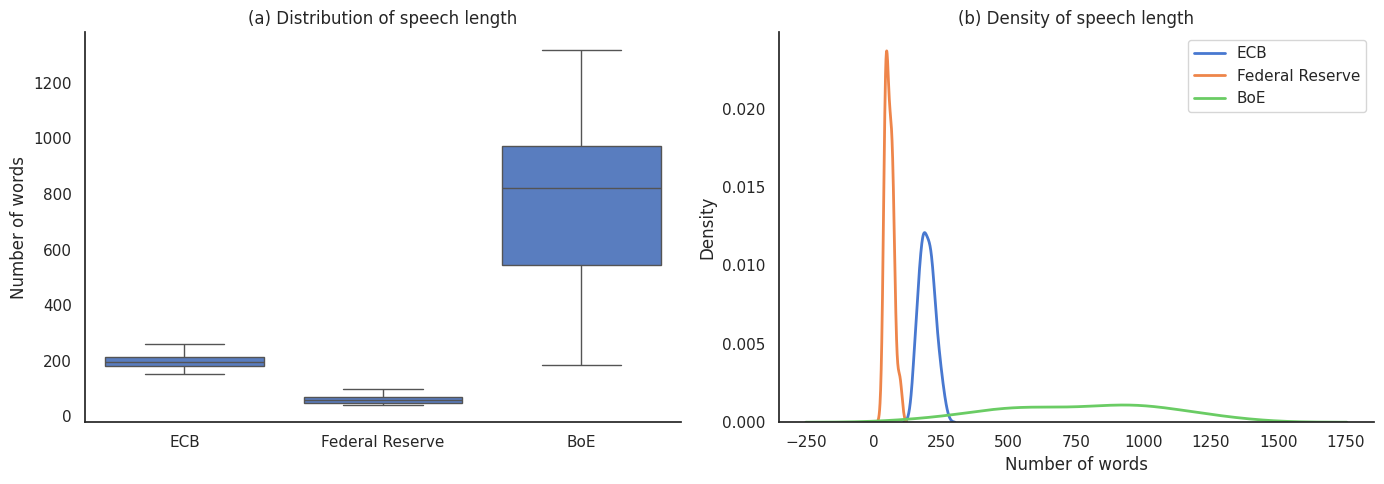

In [18]:
sns.set_theme(style="white", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raccourcir les noms
social_media['CB_short'] = social_media['CentralBank'].replace({
    'Board of Governors of the Federal Reserve': 'Federal Reserve',
    'European Central Bank': 'ECB',
    'Bank of England': 'BoE'
})

# ── (a) Boxplot ────────────────────────────────────────────
sns.boxplot(
    data=social_media,
    x='CB_short', y='n_words_final',
    ax=axes[0],
    order=['ECB', 'Federal Reserve', 'BoE']
)
axes[0].set_title("(a) Distribution of speech length")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of words")

# ── (b) KDE ────────────────────────────────────────────────
for bank in ['ECB', 'Federal Reserve', 'BoE']:
    subset = social_media[social_media['CB_short'] == bank]['n_words_final']
    sns.kdeplot(subset, ax=axes[1], label=bank, linewidth=2)

axes[1].set_title("(b) Density of speech length")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Density")
axes[1].legend(title="")

for ax in axes:
    sns.despine(ax=ax)

#plt.suptitle("Speech length by central bank — Governors & Deputy Governors, 2001–2023",
#             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Classic speeches 
This dataset comes from this article : Campiglio, E., Deyris, J., Romelli, D. and Scalisi, G., 2025. Warning words in a warming world: Central bank communication and climate change. European Economic Review [Open Access], Vol 178.

In [10]:
# Importing the preprocessed data from the first notebook (saved in the SSP Cloud) :
fs = s3fs.S3FileSystem(
    client_kwargs={"endpoint_url": "https://minio.lab.sspcloud.fr"}
)
fs.invalidate_cache()
with fs.open("lelkamel/chunks/df_filtered.csv", "rb") as f:
    df_filtered = pd.read_csv(f)
print(f"df_filtered chargé : {df_filtered.shape}")

df_filtered chargé : (2286, 19)


In [19]:
df_filtered = df_filtered[df_filtered["Year"] > 2020]

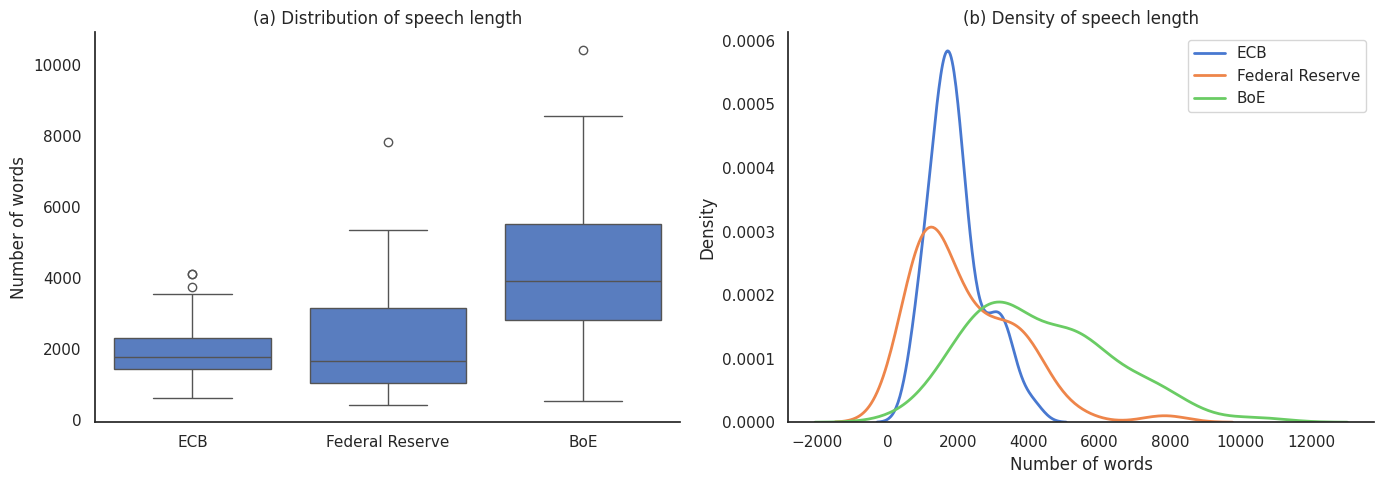

In [20]:
sns.set_theme(style="white", palette="muted")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raccourcir les noms
df_filtered['CB_short'] = df_filtered['CentralBank'].replace({
    'Board of Governors of the Federal Reserve': 'Federal Reserve',
    'European Central Bank': 'ECB',
    'Bank of England': 'BoE'
})

# ── (a) Boxplot ────────────────────────────────────────────
sns.boxplot(
    data=df_filtered,
    x='CB_short', y='n_words',
    ax=axes[0],
    order=['ECB', 'Federal Reserve', 'BoE']
)
axes[0].set_title("(a) Distribution of speech length")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of words")

# ── (b) KDE ────────────────────────────────────────────────
for bank in ['ECB', 'Federal Reserve', 'BoE']:
    subset = df_filtered[df_filtered['CB_short'] == bank]['n_words']
    sns.kdeplot(subset, ax=axes[1], label=bank, linewidth=2)

axes[1].set_title("(b) Density of speech length")
axes[1].set_xlabel("Number of words")
axes[1].set_ylabel("Density")
axes[1].legend(title="")

for ax in axes:
    sns.despine(ax=ax)

#plt.suptitle("Speech length by central bank — Governors & Deputy Governors, 2001–2023",
#             fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Comparison between the two

In [21]:
# ============================================================
# STEP 2 — Filter to 2021-2023
# ============================================================

speech_2123 = df_filtered[
    (df_filtered['Year'].between(2021, 2023)) 
].reset_index(drop=True)

# Use text_clean_final for social media
social_2123 = social_media[
    (social_media['Year'].between(2021, 2023)) 
].reset_index(drop=True)


In [ ]:
!pip install textstat
import textstat

In [28]:
# ============================================================
# STEP 3 — Compute complexity metrics
# ============================================================

def compute_complexity_simple(text):
    try:
        return {
            'flesch_reading_ease':  textstat.flesch_reading_ease(text),
            'fog_index':            textstat.gunning_fog(text),
            'flesch_kincaid_grade': textstat.flesch_kincaid_grade(text),
            'words_per_sentence':   textstat.words_per_sentence(text),
        }
    except:
        return {k: np.nan for k in [
            'flesch_reading_ease', 'fog_index',
            'flesch_kincaid_grade', 'words_per_sentence'
        ]}

# Speeches — use chunk_text
print("Computing complexity for speeches...")
speech_complexity = speech_2123['text_clean'].apply(compute_complexity_simple)
df_sc = pd.DataFrame(speech_complexity.tolist())
df_sc['medium'] = 'Speeches'
df_sc['CentralBank'] = speech_2123['CentralBank'].values

# Social media — use text_clean_final
print("Computing complexity for social media...")
social_complexity = social_2123['text_clean_final'].apply(compute_complexity_simple)
df_sm = pd.DataFrame(social_complexity.tolist())
df_sm['medium'] = 'Social Media'
df_sm['CentralBank'] = social_2123['CentralBank'].values

# Combine
df_compare = pd.concat([df_sc, df_sm], ignore_index=True)
df_compare['CB'] = df_compare['CentralBank'].map({
    'Bank of England': 'BoE',
    'European Central Bank': 'ECB', 
    'Board of Governors of the Federal Reserve': 'Fed'
})

print("\n=== Complexity comparison ===")
print(df_compare.groupby(['CB', 'medium'])[
    ['flesch_reading_ease', 'fog_index', 'flesch_kincaid_grade']
].mean().round(1))

Computing complexity for speeches...


Computing complexity for social media...

=== Complexity comparison ===
                  flesch_reading_ease  fog_index  flesch_kincaid_grade
CB  medium                                                            
BoE Social Media                 42.7       15.9                  12.5
    Speeches                     44.8       15.8                  12.9
ECB Social Media                 52.2       12.8                  10.1
    Speeches                     38.0       16.2                  13.0
Fed Social Media                 38.4       17.0                  13.4
    Speeches                     37.0       16.6                  13.6


<>:37: SyntaxWarning: invalid escape sequence '\&'
<>:37: SyntaxWarning: invalid escape sequence '\&'
/tmp/ipykernel_9785/551392482.py:37: SyntaxWarning: invalid escape sequence '\&'
  'BoE \& ECB, 2021--2023',


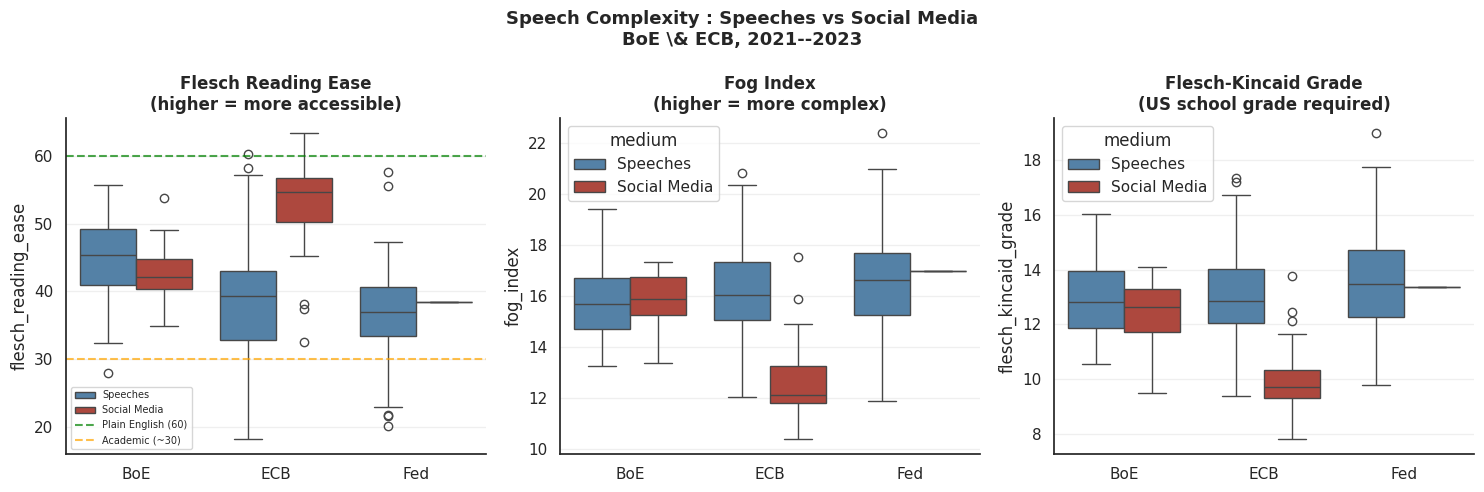

In [29]:
# ============================================================
# STEP 4 — Complexity boxplot figure
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('flesch_reading_ease', 'Flesch Reading Ease\n(higher = more accessible)'),
    ('fog_index',           'Fog Index\n(higher = more complex)'),
    ('flesch_kincaid_grade','Flesch-Kincaid Grade\n(US school grade required)'),
]

palette = {'Speeches': 'steelblue', 'Social Media': '#c0392b'}

for ax, (metric, title) in zip(axes, metrics):
    sns.boxplot(
        data=df_compare,
        x='CB', y=metric,
        hue='medium',
        palette=palette,
        ax=ax,
        order=['BoE', 'ECB', 'Fed']
    )
    if metric == 'flesch_reading_ease':
        ax.axhline(y=60, color='green', linestyle='--',
                   alpha=0.7, label='Plain English (60)')
        ax.axhline(y=30, color='orange', linestyle='--',
                   alpha=0.7, label='Academic (~30)')
        ax.legend(fontsize=7)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Speech Complexity : Speeches vs Social Media\n'
             'BoE \& ECB, 2021--2023',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()